In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
#import dataset
import kagglehub
# Download latest version
path = kagglehub.dataset_download("mathchi/diabetes-data-set")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\kochu\.cache\kagglehub\datasets\mathchi\diabetes-data-set\versions\1


C:\Users\kochu\AppData\Local\Temp\ipykernel_25876\495651163.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\kochu\AppData\Local\Temp\ipykernel_25876\495651163.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


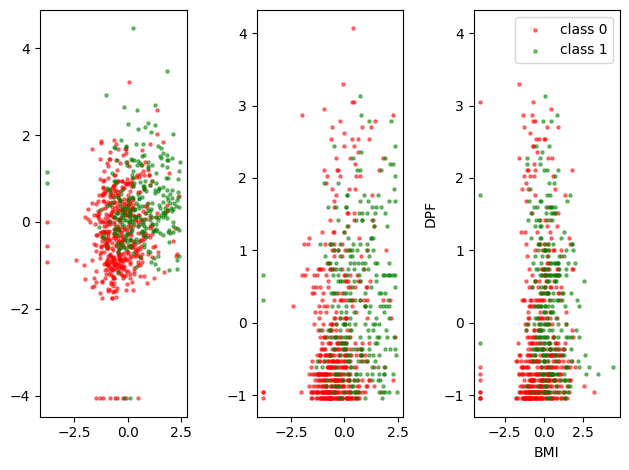

In [111]:
datadb=pd.read_csv("diabetes.csv")
# datadb.info()
# datadb.isnull().sum().sum()
datadb=datadb.drop_duplicates()

x=datadb[["Glucose","BMI","Age"]].values
y=datadb["Outcome"].values
m,n=x.shape
x = (x - x.mean(axis=0)) / x.std(axis=0)

fig,axis=plt.subplots(1,3)
gch0={"color":"red","alpha":0.5,"s":5}
gch1={"color":"green","alpha":0.5,"s":5}

axis[0].scatter(x[y==0,0],x[y==0,1],**gch0,label="class 0")
axis[0].scatter(x[y==1,0],x[y==1,1],**gch1,label="class 1")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.legend()

axis[1].scatter(x[y==0,0],x[y==0,2],**gch0,label="class 0")
axis[1].scatter(x[y==1,0],x[y==1,2],**gch1,label="class 1")
plt.xlabel("Glucose")
plt.ylabel("DPF")
plt.legend()

axis[2].scatter(x[y==0,1],x[y==0,2],**gch0,label="class 0")
axis[2].scatter(x[y==1,1],x[y==1,2],**gch1,label="class 1")
plt.xlabel("BMI")
plt.ylabel("DPF")
plt.legend()

plt.tight_layout()
plt.show()

In [112]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [113]:
def cost_f(x,y,w,b):
    z=np.dot(x,w)+b
    g=sigmoid(z)
    cost=(1/m)*np.sum(-y*np.log(g)-(1-y)*np.log(1-g))
    return cost 

In [114]:
def grad(x,y,w,b):
    z=np.dot(x,w)+b
    g=sigmoid(z)
    dc_db=(1/m)*np.sum(g-y)
    dc_dw=(1/m)*np.dot(x.T,(g-y))

    return dc_db,dc_dw

In [115]:
def grad_desc(x,y,alpha,iteration):
    w=np.zeros(n)
    b=0
    for i in range (iteration):
        dc_db,dc_dw=grad(x,y,w,b)
        w=w-alpha*dc_dw
        b=b-alpha*dc_db
        if i%1000==0:
            print(cost_f(x,y,w,b))
    return w,b

In [116]:
def predict(x,w,b):
    pred=np.zeros(m)
    for i in range(m):
        z=np.dot(x,w)+b
        g=sigmoid(z)
        if g[i]>0.5:
            pred[i]=1
        else:
            return 0
    return pred

In [117]:
alpha=0.0001
iteration=20000
fw,fb=grad_desc(x,y,alpha,iteration)
predictions=predict(x,fw,fb)
accuracy=np.mean(predictions==y)*100
print(f"accuracy:{accuracy}")

0.6931367165230695
0.6829979808794107
0.6734814301644549
0.6645468064030844
0.6561557942730701
0.6482721152069342
0.6408615717246914
0.6338920503675007
0.6273334913799493
0.6211578326782968
0.6153389347984575
0.6098524925671028
0.6046759382760591
0.5997883402277198
0.5951702996955412
0.590803848627275
0.5866723498138895
0.5827604007496541
0.5790537420087799
0.575539170649074
accuracy:65.10416666666666
